<div style="
background-color:#EAEAEA;
padding:20px;
border-left:5px solid #6C757D;
border-radius:6px;">

<table style="width:100%; border:none;">
<tr style="border:none;">

<td style="border:none; vertical-align:top;">

<h1 style="font-size:32px; margin-top:0;">
Master's Thesis
</h1>

<hr style="margin:16px 0 22px 0;">

<p style="font-size:22px; line-height:1.5; margin:0;">
<strong>Master's Degree in Advanced Physics</strong> - 
<strong>Universitat de Val?ncia</strong>
</p>

<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">
This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:
</p>

<div style="
font-size:25px;
font-weight:700;
line-height:1.3;
margin-top:14px;
margin-bottom:26px;">
Fast Simulation of Neutrino Oscillations in Matter
</div>

<p style="font-size:14px; line-height:1.55;">
<strong>Author</strong><br>
Juan Ramon Diaz Santos - 
<a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a>
</p>

<p style="font-size:14px; line-height:1.55;">
<strong>Supervisors</strong><br>
Roberto Ruiz de Austri Bazan ?
<a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>
Michele Lucente ?
<a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a>
</p>

<p style="font-size:14px; line-height:1.55; margin-bottom:0;">
<strong>Date</strong><br>
September 2026
</p>

</td>

<td style="
border:none;
width:230px;
padding-left:25px;
text-align:right;
vertical-align:top;">

<img src="../../logo_uv.png"
     alt="Universitat de Val?ncia"
     style="width:200px; margin-top:5px;">

</td>

</tr>
</table>

</div>

# Atmosphere Analysis 1 - Geometry and Density
---

This notebook studies the geometrical ingredients used for atmospheric-neutrino propagation in `tpeanuts`: detector zenith angles, surface-intersection angles, detector depth, atmospheric and underground chord lengths, and the density profiles exposed by the atmosphere package.

---

## Table of Contents

| # | Section |
|---|---------|
| [0](#0.-Theory-Background) | **Theory Background**: atmospheric geometry, detector depth, chord lengths and density profiles |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** - paths, parameters and local helpers |
| [3](#3.-Detector-and-Surface-Angle-Geometry) | **Detector and Surface Angle Geometry** |
| [4](#4.-Atmospheric-Height-and-Atmospheric-Depth) | **Atmospheric Height and Atmospheric Depth** |
| [5](#5.-Atmospheric-and-Earth-Chord-Lengths) | **Atmospheric and Earth Chord Lengths** |
| [6](#6.-Atmospheric-Density-Profiles) | **Atmospheric Density Profiles** |
| [7](#7.-Difference-with-respect-to-PyMSIS-Reference) | **Difference with respect to PyMSIS Reference** |
| [∑](#8.-Summary) | **Summary** |

## 0. Theory Background

### 0.1 Geometry Parameters and Notation

This notebook uses a spherical Earth geometry. Unless otherwise stated, all distances are
expressed in km and all angles in the figures are shown in degrees.

| Symbol | Meaning | Convention |
|--------|---------|------------|
| $R_\oplus$ | Earth radius | Fixed reference radius used by the geometry helpers |
| $d$ | Detector depth | Positive below the Earth surface |
| $r_d$ | Detector radial coordinate | $r_d=R_\oplus-d$ |
| $h$ | Production altitude | Height above the Earth surface where the atmospheric neutrino is produced |
| $\theta$ | Detector zenith angle | MCEq-style convention: $0^\circ$ downward, $90^\circ$ horizontal, $180^\circ$ upward |
| $\eta$ | Peanuts nadir angle | $\eta=\pi-\theta$; $\eta=0$ is vertically upward through the Earth |
| $\alpha$ | Surface-intersection angle | Angle at the Earth surface corresponding to the detector ray; differs from $\theta$ when $d>0$ |
| $s$ | Path coordinate | Distance measured from the detector along the back-traced neutrino ray |
| $X$ | Atmospheric column depth | $X(h)$ for vertical depth or $X(\theta)$ for slant depth, obtained by integrating density along a path |
| $L_\mathrm{atm}$ | Atmospheric chord length | Portion of the trajectory above the Earth surface |
| $L_\mathrm{earth}$ | Underground/Earth chord length | Detector-to-surface segment for downward paths and Earth chord contribution for upward paths |

The core radial relation used to evaluate altitude along a detector ray is

$$
r(s)^2 = r_d^2+s^2+2r_d s\cos\theta,
\qquad h(s)=r(s)-R_\oplus .
$$

---

### 0.2 Atmospheric Neutrino Geometry

Atmospheric neutrinos are produced by cosmic-ray cascades at altitude $h$ and arrive at a detector located at depth $d$. 

The atmosphere module uses the MCEq-style detector **zenith angle convention**:

$$
\theta=0^\circ\quad\text{vertical downward},\qquad
\theta=90^\circ\quad\text{horizontal},\qquad
\theta=180^\circ\quad\text{vertical upward}.
$$

The detector radius is $r_d=R_\oplus-d$. Spherical geometry is essential near the horizon because the atmospheric path can become much longer than the vertical production height.

---

### 0.3 Detector Zenith Angle and Surface Angle

For an underground detector, the detector angle $\theta$ and the angle $\alpha$ at the Earth-surface intersection are not identical. If both are measured with respect to the local radial direction of the same straight ray, the sine-rule relation is equivalently the conservation of the impact parameter,

$$
b = r_d\sin\theta = R_\oplus\sin\alpha.
$$

Therefore, `alpha_surface_to_theta_detector` and `theta_detector_to_alpha_surface` implements

$$
\alpha = \arcsin \Big(\frac{r_d}{R_\oplus}\sin\theta\Big),
\qquad
\theta = \arcsin \Big(\frac{R_\oplus}{r_d}\sin\alpha\Big).
$$

For a surface detector $d=0$, one recovers $\alpha=\theta$. For $d>0$, $r_d<R_\oplus$, so the corresponding surface angle is slightly smaller than the detector angle, except that the difference only becomes noticeable close to the horizon.

For the conversion to \eta nadir angle in the peanuts and tpeanuts convenction, the functions `theta_to_eta` and `eta_to_theta` respectively:

$$
\eta = \pi - \theta \qquad \theta = \pi - \eta 
$$

---

### 0.4 Detector Depth and Horizon Correction

The limiting surface angle for a ray that can reach an underground detector is (`alpha_max_for_detector_depth`)

$$
\alpha_\mathrm{max}(d)=\arcsin\left(\frac{r_d}{R_\oplus}\right)
=\arcsin\left(\frac{R_\oplus-d}{R_\oplus}\right).
$$

This follows from the horizon detector ray $\theta=90^\circ$, for which $\sin\alpha_\mathrm{max}=r_d/R_\oplus$. It is slightly smaller than $90^\circ$ for underground detectors. The effect is tiny for kilometre-scale depths, but it is useful for stable near-horizon grids.

---

### 0.5 Atmospheric Height and Atmospheric Depth

Along a ray measured from the detector, the altitude is given by `altitude_along_detector_path`, implementing:

$$
h(s)=\sqrt{r_d^2+s^2+2r_d s\cos\theta}-R_\oplus.
$$

The vertical atmospheric depth is

$$
X(h)=\int_h^\infty \rho(h')\,dh',
$$

while an inclined trajectory samples the slant depth

$$
X(\theta)=\int_\mathrm{path}\rho[h(s)]\,ds.
$$

These column-density variables are standard in atmospheric cascade calculations.

---

### 0.6 Atmospheric and Earth Chord Lengths

For a production shell at altitude $h$, define

$$
r_d = R_\oplus-d,\qquad r_h=R_\oplus+h.
$$

The full detector-to-production baseline implemented by `total_path_length` is the
positive intersection of the detector ray with the production shell,

$$
L_\mathrm{total}(h,\theta,d)
= -r_d\cos\theta
+ \sqrt{r_h^2-r_d^2\sin^2\theta}.
$$

The underground or Earth part implemented by `underground_path_length` is the analogous
intersection with the Earth surface,

$$
L_\mathrm{earth}(\theta,d)
= -r_d\cos\theta
+ \sqrt{R_\oplus^2-r_d^2\sin^2\theta}.
$$

The atmospheric part implemented by `atmosphere_path_length` is then the difference
between both spherical intersections,

$$
L_\mathrm{atm}(h,\theta,d)
= L_\mathrm{total}(h,\theta,d)-L_\mathrm{earth}(\theta,d).
$$

The atmosphere density is sampled only along $L_\mathrm{atm}$, while $L_\mathrm{earth}$ describes the underground detector-to-surface part and, for upward directions, the Earth-scale chord.

---

### 0.7 Atmospheric Density Profiles

`atmosphere_density` exposes several backends:

| Source | Description |
|--------|-------------|
| `exponential` | Analytic $ \rho(h)=\rho_0 e^{-h/H} $ profile |
| `file` | Two-column altitude-density table, here `data/density/atmosphere_density_profile.csv` |
| `nusquids` / `earthatm` | nuSQuIDS EarthAtm-style reference |
| `mceq` | Optional MCEq density backend; the bundled MCEq table is accessed through `file` |
| `pymsis` / `msis` | Optional PyMSIS empirical atmosphere backend |

The output can be mass density in g/cm$^3$ or electron density in mol/cm$^3$, using an electron fraction $Y_e$.

---

**References**

- T. K. Gaisser, R. Engel and E. Resconi, *Cosmic Rays and Particle Physics*, Cambridge University Press.
- A. Fedynitch et al., *MCEq - numerical code for inclusive lepton flux calculations*, PoS ICRC2015, 1129.
- J. M. Picone et al., *NRLMSISE-00 empirical model of the atmosphere*, J. Geophys. Res. **107**, 1468 (2002).
- C. A. Argüelles et al., *nuSQuIDS: a toolbox for neutrino propagation*, Comput. Phys. Commun. **221**, 151 (2017).

## 1. Libraries

In [1]:
import math
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from tpeanuts.util.context import RuntimeContext
from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show, to_numpy
from tpeanuts.medium.atmosphere.geometry import (
    alpha_max_for_detector_depth,
    atmosphere_path_grid,
    atmosphere_path_length,
    theta_detector_to_alpha_surface,
    underground_path_length,
)
from tpeanuts.medium.atmosphere.density import atmosphere_density

try:
    from tpeanuts.external.mceq.config import MCEqModelConfig
    mceq_ok = True
except ImportError:
    MCEqModelConfig = None
    mceq_ok = False

try:
    from tpeanuts.external.pymsis.density import PyMSISatmosphereConfig
    pymsis_ok = True
except ImportError:
    PyMSISatmosphereConfig = None
    pymsis_ok = False

from tpeanuts.external.nusquids.core import NuSQuIDSConfig

print(f"Torch {torch.__version__}")

from tpeanuts.util.math import numpy_trapezoid

# ------------------------------------------------------------------
# Optional dependencies
# ------------------------------------------------------------------
print(f"MCEq      : {'OK' if mceq_ok else 'NOT FOUND'}")
print(f"PyMSIS    : {'OK' if pymsis_ok else 'NOT FOUND'}")

Torch 2.3.1
MCEq      : OK
PyMSIS    : OK


## 2. Paths and Configuration

### 2.1 Paths

`load_notebook_config()` resolves the package root, applies the shared plotting style, and provides the output root. The output directory is built from the notebook relative path below `notebooks/`, so all figures are saved under `analysis/atmosphere/`.

In [2]:
config = load_notebook_config()
ctx = RuntimeContext.resolve(config.device, config.dtype)

PROJECT_DIR = config.package_dir
OUTPUT_DIR = config.output_dir("analysis", "atmosphere")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = config.data_dir
ATMOSPHERE_DENSITY_FILE = DATA_DIR / "density" / "atmosphere_density_profile.csv"

print(f"Package dir : {PROJECT_DIR}")
print(f"Output dir  : {OUTPUT_DIR}")
print(f"Atmosphere density file   : {ATMOSPHERE_DENSITY_FILE}")
print(f"Device      : {ctx.device}   dtype: {ctx.dtype}")

Package dir : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Output dir  : v:\output\analysis\atmosphere
Atmosphere density file   : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\density\atmosphere_density_profile.csv
Device      : cpu   dtype: torch.float64


### 2.2 Configuration

The geometry is evaluated from vertical downward to vertical upward. Detector depths cover surface, shallow underground and deep underground examples. A representative production altitude is used for chord diagnostics, while density profiles are sampled over the lower and middle atmosphere.

| Parameter | Value | Description |
|-----------|-------|-------------|
| Detector depths | 0, 0.5, 1, 2, 4 km | Representative depths below the surface |
| Zenith grid | 0-180 deg | Detector atmospheric zenith angle |
| Near-horizon grid | 0-89.95 deg | Stable grid for the theta-alpha map |
| Production height | 20 km | Representative atmospheric-neutrino production altitude |
| Altitude grid | 0-120 km, 80 points | Density-profile comparison range |
| Density sources | exponential, file, nusquids, pymsis | Backends tested by default; `mceq` is optional and represented by the bundled MCEq table through `file` |
| Reference profile | pymsis, when available | Empirical reference used for residuals |

**Expected results:** the configuration output should report a valid project path, output path, runtime device/dtype, and the MCEq reference density file.

In [3]:
SHOW_PLOTS = config.show_plots
DTYPE = ctx.dtype
DEVICE = ctx.device

DEPTHS_KM = torch.tensor([0.0, 0.5, 1.0, 2.0, 4.0], dtype=DTYPE, device=DEVICE)
THETA_SURFACE_GRID_DEG = torch.linspace(0.0, 89.95, 500, dtype=DTYPE, device=DEVICE)
THETA_FULL_GRID_DEG = torch.linspace(0.0, 180.0, 721, dtype=DTYPE, device=DEVICE)
DEPTH_FINE_KM = torch.linspace(0.0, 5.0, 300, dtype=DTYPE, device=DEVICE)
PRODUCTION_HEIGHT_KM = torch.tensor(20.0, dtype=DTYPE, device=DEVICE)
ALTITUDE_GRID_KM = torch.linspace(0.0, 120.0, 80, dtype=DTYPE, device=DEVICE)
SLANT_THETA_GRID_DEG = torch.tensor([0.0, 30.0, 60.0, 80.0], dtype=DTYPE, device=DEVICE)

PYMSIS_CONFIG = PyMSISatmosphereConfig(context=ctx) if PyMSISatmosphereConfig is not None else None

print(f"Production height: {float(PRODUCTION_HEIGHT_KM):.1f} km")
print(f"Detector depths  : {to_numpy(DEPTHS_KM)} km")
print(f"Altitude grid    : {ALTITUDE_GRID_KM.numel()} points")
print(f"PyMSIS available : {PYMSIS_CONFIG is not None}")

Production height: 20.0 km
Detector depths  : [0.  0.5 1.  2.  4. ] km
Altitude grid    : 80 points
PyMSIS available : True


### 2.3 Local Helpers

Only small notebook-local helpers are defined here. They wrap repeated density-backend calls, compute stable relative differences, and numerically integrate atmospheric depth from sampled mass-density profiles.

**Expected results:** no physics output is produced here; these helpers standardise later calculations.

In [4]:
def safe_rel_delta(candidate, reference, floor=1.0e-30):
    candidate = np.asarray(candidate, dtype=float)
    reference = np.asarray(reference, dtype=float)
    return (candidate - reference) / np.maximum(np.abs(reference), floor)


def vertical_depth_from_density(h_km, rho_gcm3):
    h_np = np.asarray(to_numpy(h_km), dtype=float)
    rho_np = np.asarray(to_numpy(rho_gcm3), dtype=float)
    h_cm = h_np * 1.0e5
    depth = np.zeros_like(rho_np)
    for i in range(len(h_np)):
        depth[i] = numpy_trapezoid(rho_np[i:], x=h_cm[i:])
    return depth


def evaluate_density_source(source, h_km, *, density_type="mass_density"):
    h_km = torch.clamp(torch.as_tensor(h_km, device=DEVICE, dtype=DTYPE), min=0.0)
    kwargs = {}
    if source == "file":
        kwargs["density_file"] = str(ATMOSPHERE_DENSITY_FILE)
    elif source in {"nusquids", "earthatm", "nusquids_earthatm"}:
        kwargs["nusquids_config"] = NuSQuIDSConfig()
    elif source == "exponential":
        kwargs["nusquids_config"] = NuSQuIDSConfig()
    elif source == "mceq":
        kwargs["mceq_config"] = MCEqModelConfig()
    elif source in {"pymsis", "msis"}:
        if PYMSIS_CONFIG is None:
            raise ImportError("PyMSIS backend is not available.")
        kwargs["pymsis_config"] = PYMSIS_CONFIG
    return atmosphere_density(h_km, source=source, density_type=density_type, context=ctx, **kwargs)


def collect_density_profiles(h_km, sources, *, density_type="mass_density"):
    profiles, rows = {}, []
    for source in sources:
        try:
            profiles[source] = evaluate_density_source(source, h_km, density_type=density_type)
            rows.append({"source": source, "available": True, "message": "ok"})
        except Exception as exc:
            rows.append({"source": source, "available": False, "message": str(exc).splitlines()[0]})
    return profiles, pd.DataFrame(rows)

## 3. Detector and Surface Angle Geometry

This section studies how detector zenith angle `theta` maps to the surface-intersection angle `alpha` for different detector depths.

**Expected results:** for zero depth, alpha and theta overlap. For increasing depth, deviations remain small except close to the horizon.

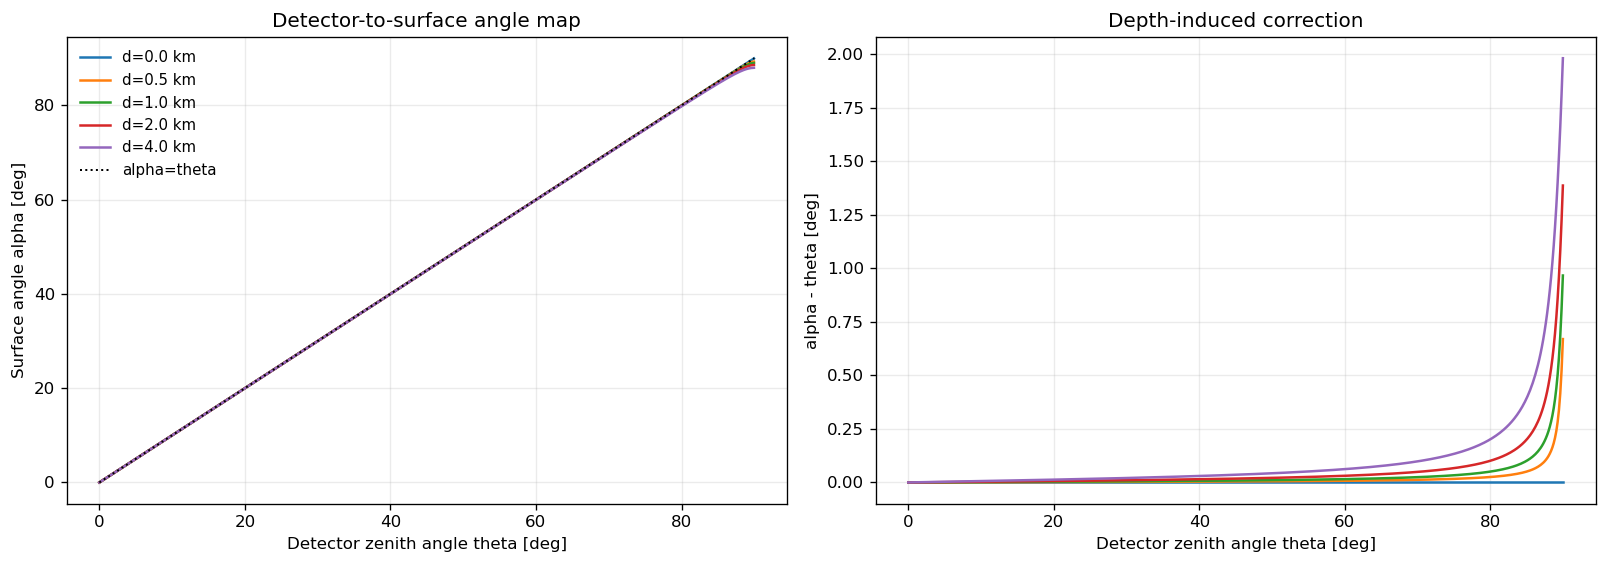

v:\output\analysis\atmosphere\atmosphere1_theta_alpha_depth_relation.png


,depth_km,alpha_max_deg,horizon_shift_deg,alpha(theta=90 deg)_deg
0,0.0,90.000000,0.000000,90.000000
1,0.5,89.282170,0.717830,89.282170
2,1.0,88.984828,1.015172,88.984828
3,2.0,88.564312,1.435688,88.564312
4,4.0,87.969577,2.030423,87.969577


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), sharex=True)
for depth in DEPTHS_KM:
    alpha = theta_detector_to_alpha_surface(THETA_SURFACE_GRID_DEG, depth, device=DEVICE, dtype=DTYPE)
    label = f"d={float(depth):.1f} km"
    axes[0].plot(to_numpy(THETA_SURFACE_GRID_DEG), to_numpy(alpha), label=label)
    axes[1].plot(to_numpy(THETA_SURFACE_GRID_DEG), to_numpy(THETA_SURFACE_GRID_DEG- alpha), label=label)
axes[0].plot([0, 90], [0, 90], color="black", linestyle=":", linewidth=1.2, label="alpha=theta")
axes[0].set_ylabel("Surface angle alpha [deg]")
axes[1].set_ylabel("alpha - theta [deg]")
for ax in axes:
    ax.set_xlabel("Detector zenith angle theta [deg]")
    ax.grid(alpha=0.25)
axes[0].legend(frameon=False, fontsize=9)
axes[0].set_title("Detector-to-surface angle map")
axes[1].set_title("Depth-induced correction")
fig.tight_layout()
save_and_show("atmosphere1_theta_alpha_depth_relation.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

angle_geometry_table = pd.DataFrame([
    {
        "depth_km": float(depth),
        "alpha_max_deg": float(alpha_max_for_detector_depth(depth, device=DEVICE, dtype=DTYPE)),
        "horizon_shift_deg": float(90.0 - alpha_max_for_detector_depth(depth, device=DEVICE, dtype=DTYPE)),
        "alpha(theta=90 deg)_deg": float(theta_detector_to_alpha_surface(torch.tensor(90.0, dtype=DTYPE, device=DEVICE), depth, device=DEVICE, dtype=DTYPE)),
    }
    for depth in DEPTHS_KM
])
display(angle_geometry_table)

### 3.2 Horizontal Detector Direction theta = pi/2 vs Depth

The exact horizontal direction at the detector is where depth corrections are largest. The limiting detector angle is slightly smaller than 90 deg for nonzero depth.

**Expected results:** the horizon shift grows monotonically with depth, while remaining well below one degree for kilometre-scale underground detectors.

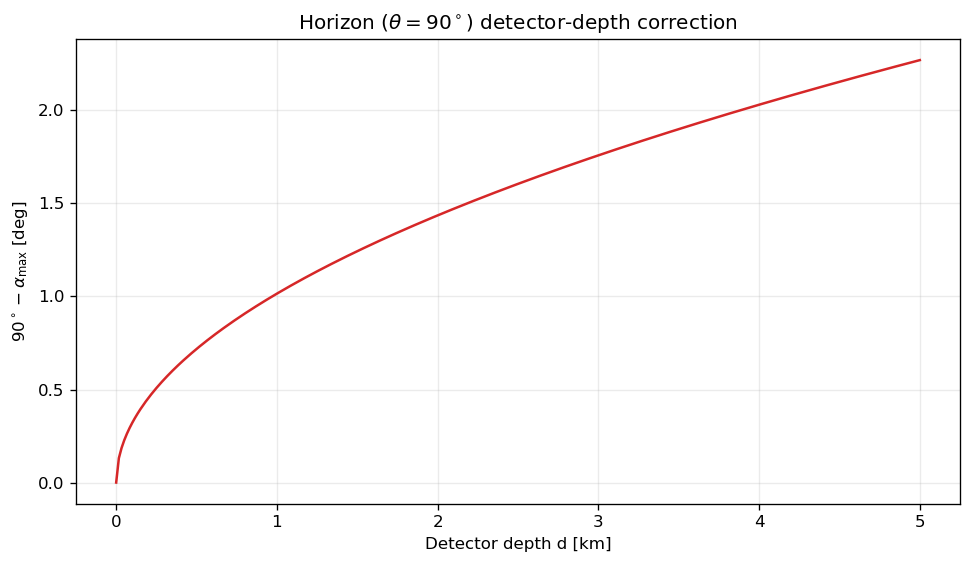

v:\output\analysis\atmosphere\atmosphere1_horizontal_theta_depth_shift.png


In [6]:
alpha_max_depth = alpha_max_for_detector_depth(DEPTH_FINE_KM, device=DEVICE, dtype=DTYPE)
fig, ax = plt.subplots(figsize=(8.2, 4.8))
ax.plot(to_numpy(DEPTH_FINE_KM), 90.0 - to_numpy(alpha_max_depth), color="tab:red")
ax.set_xlabel("Detector depth d [km]")
ax.set_ylabel(r"$90^\circ - \alpha_\mathrm{max}$ [deg]")
ax.set_title(r"Horizon ($\theta=90^\circ$) detector-depth correction")
ax.grid(alpha=0.25)
fig.tight_layout()
save_and_show("atmosphere1_horizontal_theta_depth_shift.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 4. Atmospheric Height and Atmospheric Depth

This section connects path coordinate, altitude and atmospheric depth.

**Expected results:** vertical trajectories reach a given altitude over the shortest distance. Near-horizontal trajectories require much longer slant distances.

MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)


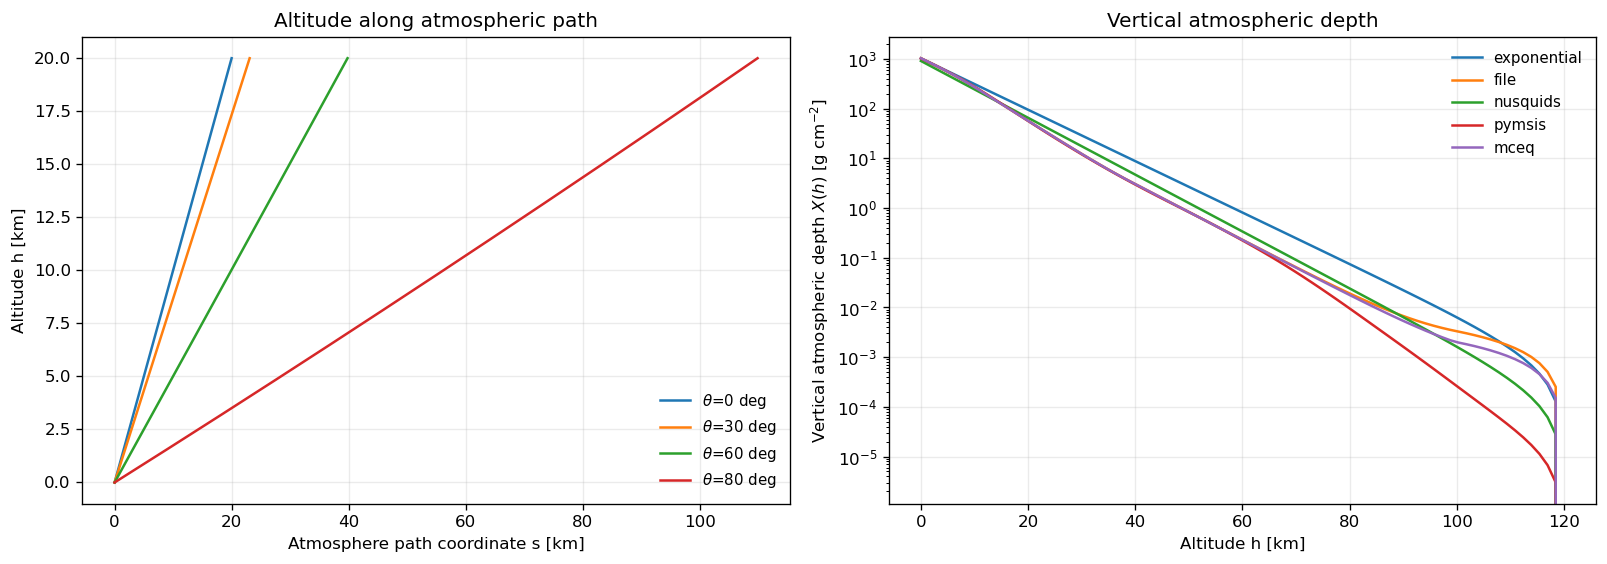

v:\output\analysis\atmosphere\atmosphere1_height_and_vertical_depth.png


,source,available,message
0,exponential,True,ok
1,file,True,ok
2,nusquids,True,ok
3,pymsis,True,ok
4,mceq,True,ok


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
for theta in SLANT_THETA_GRID_DEG:
    s_grid, h_grid = atmosphere_path_grid(PRODUCTION_HEIGHT_KM, theta, depth_km=0.0, n_steps=300, device=DEVICE, dtype=DTYPE)
    axes[0].plot(to_numpy(s_grid), to_numpy(h_grid), label=fr"$\theta$={float(theta):.0f} deg")

mass_profiles, density_availability = collect_density_profiles(
    ALTITUDE_GRID_KM, ["exponential", "file", "nusquids", "pymsis", "mceq"], density_type="mass_density"
)
for source, rho in mass_profiles.items():
    axes[1].semilogy(to_numpy(ALTITUDE_GRID_KM), vertical_depth_from_density(ALTITUDE_GRID_KM, rho), label=source)

axes[0].set_xlabel("Atmosphere path coordinate s [km]")
axes[0].set_ylabel("Altitude h [km]")
axes[0].set_title("Altitude along atmospheric path")
axes[1].set_xlabel("Altitude h [km]")
axes[1].set_ylabel(r"Vertical atmospheric depth $X(h)$ [g cm$^{-2}$]")
axes[1].set_title("Vertical atmospheric depth")
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
save_and_show("atmosphere1_height_and_vertical_depth.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)
display(density_availability)

### 4.2 Slant Atmospheric Depth at Detector

The slant atmospheric depth integrates the mass density along the atmospheric segment for several detector zenith angles.

**Expected results:** slant depth increases with zenith angle and becomes much larger near the horizon.

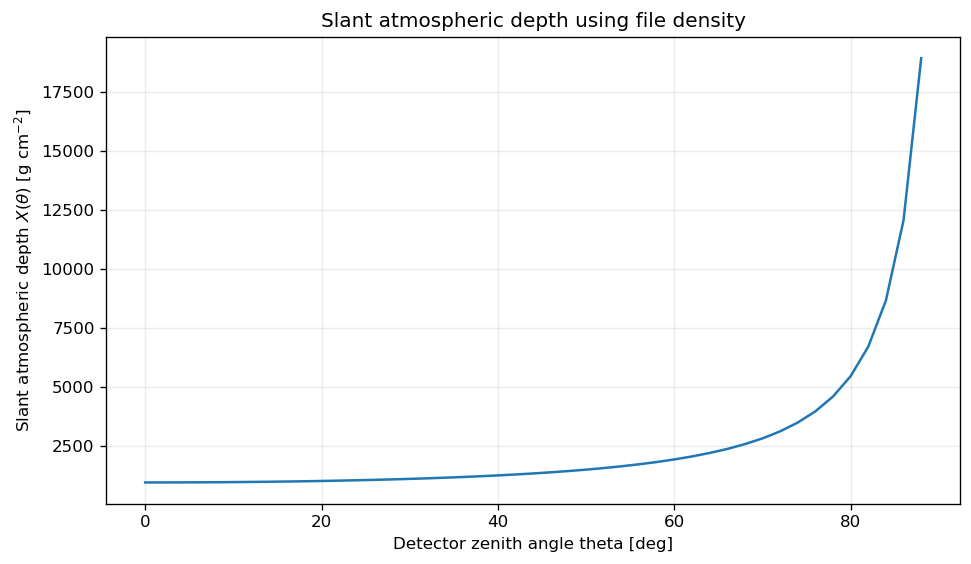

v:\output\analysis\atmosphere\atmosphere1_slant_atmospheric_depth.png


,theta_deg,X_slant_g_cm2,source
0,0.0,979.267218,file
1,2.0,979.862961,file
2,4.0,981.653815,file
3,6.0,984.650704,file
4,8.0,988.872018,file


In [8]:
source_for_slant = "file" if "file" in mass_profiles else "exponential"
slant_rows = []
for theta in torch.linspace(0.0, 88.0, 45, dtype=DTYPE, device=DEVICE):
    s_grid, h_grid = atmosphere_path_grid(PRODUCTION_HEIGHT_KM, theta, depth_km=0.0, n_steps=500, device=DEVICE, dtype=DTYPE)
    rho_path = evaluate_density_source(source_for_slant, h_grid, density_type="mass_density")
    slant_rows.append({
        "theta_deg": float(theta),
        "X_slant_g_cm2": numpy_trapezoid(to_numpy(rho_path), x=to_numpy(s_grid) * 1.0e5),
        "source": source_for_slant,
    })
slant_depth_table = pd.DataFrame(slant_rows)
fig, ax = plt.subplots(figsize=(8.2, 4.8))
ax.plot(slant_depth_table["theta_deg"], slant_depth_table["X_slant_g_cm2"], color="tab:blue")
ax.set_xlabel("Detector zenith angle theta [deg]")
ax.set_ylabel(r"Slant atmospheric depth $X(\theta)$ [g cm$^{-2}$]")
ax.set_title(f"Slant atmospheric depth using {source_for_slant} density")
ax.grid(alpha=0.25)
fig.tight_layout()
save_and_show("atmosphere1_slant_atmospheric_depth.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)
display(slant_depth_table.head())

## 5. Atmospheric and Earth Chord Lengths

The detector-to-production trajectory is decomposed into atmospheric and underground/Earth chords.

**Expected results:** atmospheric paths are short for vertical downward trajectories and grow near the horizon. Underground paths grow with detector depth and become Earth-scale for upward trajectories.

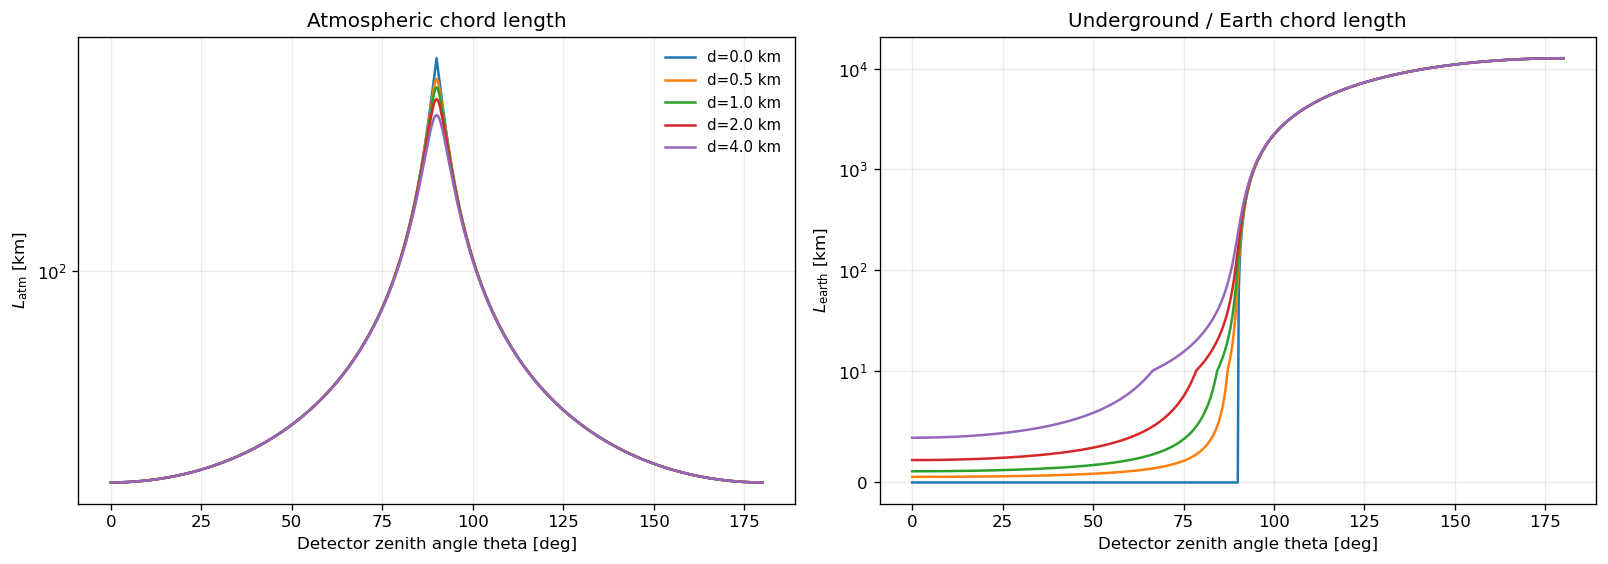

v:\output\analysis\atmosphere\atmosphere1_chord_lengths_vs_theta.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), sharex=True)
for depth in DEPTHS_KM:
    L_atm = atmosphere_path_length(PRODUCTION_HEIGHT_KM, THETA_FULL_GRID_DEG, depth_km=depth, device=DEVICE, dtype=DTYPE, check_geometry=False)
    L_und = underground_path_length(THETA_FULL_GRID_DEG, depth_km=depth, device=DEVICE, dtype=DTYPE, check_geometry=False)
    label = f"d={float(depth):.1f} km"
    axes[0].plot(to_numpy(THETA_FULL_GRID_DEG), to_numpy(L_atm), label=label)
    axes[1].plot(to_numpy(THETA_FULL_GRID_DEG), to_numpy(L_und), label=label)
axes[0].set_ylabel(r"$L_\mathrm{atm}$ [km]")
axes[1].set_ylabel(r"$L_\mathrm{earth}$ [km]")
for ax in axes:
    ax.set_xlabel("Detector zenith angle theta [deg]")
    ax.set_yscale("symlog", linthresh=10.0)
    ax.grid(alpha=0.25)
axes[0].legend(frameon=False, fontsize=9)
axes[0].set_title("Atmospheric chord length")
axes[1].set_title("Underground / Earth chord length")
fig.tight_layout()
save_and_show("atmosphere1_chord_lengths_vs_theta.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 5.2 Depth Dependence of the Chord Decomposition

Representative angles are tabulated to show where detector depth changes the baseline most strongly.

**Expected results:** depth corrections are small compared with long upward-going baselines, but visible in the underground segment and near the horizon.

,depth_km,theta_deg,L_atm_km,L_earth_km,L_total_km
0,0.0,0.0,20.000000,0.000000e+00,20.000000
1,0.0,60.0,39.813977,-4.547474e-13,39.813977
2,0.0,85.0,195.439712,2.273737e-13,195.439712
3,0.0,90.0,505.212826,-3.901112e-13,505.212826
4,0.0,120.0,39.813977,6.371000e+03,6410.813977
5,0.0,180.0,20.000000,1.274200e+04,12762.000000
6,0.5,0.0,20.000000,5.000000e-01,20.500000
7,0.5,60.0,39.804722,9.998823e-01,40.804605
8,0.5,85.0,193.974726,5.707744e+00,199.682469
9,0.5,90.0,431.662005,7.981698e+01,511.478983


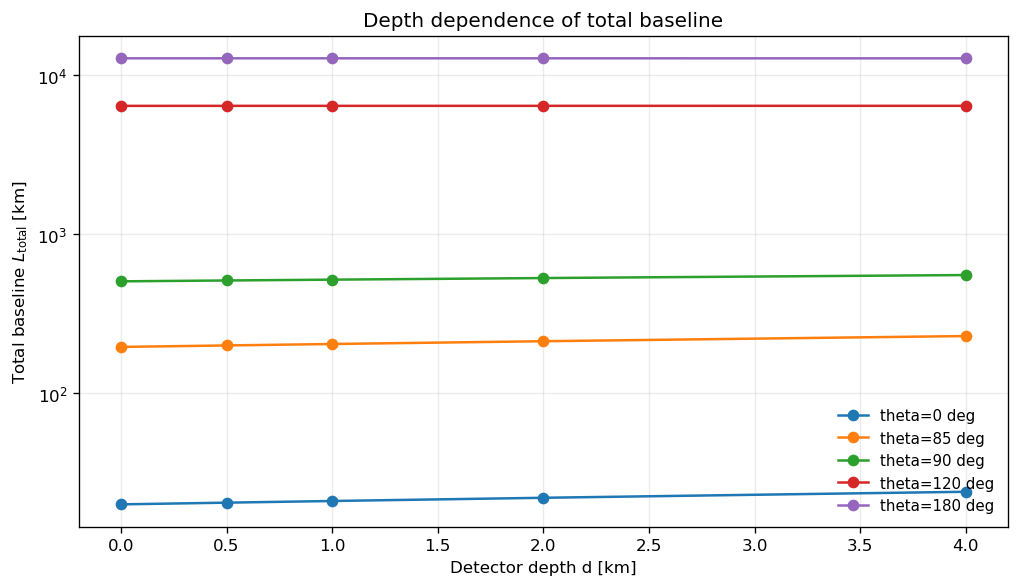

v:\output\analysis\atmosphere\atmosphere1_chord_depth_dependence.png


In [10]:
probe_thetas = torch.tensor([0.0, 60.0, 85.0, 90.0, 120.0, 180.0], dtype=DTYPE, device=DEVICE)
rows = []
for depth in DEPTHS_KM:
    for theta in probe_thetas:
        L_atm = atmosphere_path_length(PRODUCTION_HEIGHT_KM, theta, depth_km=depth, device=DEVICE, dtype=DTYPE, check_geometry=False)
        L_und = underground_path_length(theta, depth_km=depth, device=DEVICE, dtype=DTYPE, check_geometry=False)
        rows.append({"depth_km": float(depth), "theta_deg": float(theta), "L_atm_km": float(L_atm), "L_earth_km": float(L_und), "L_total_km": float(L_atm + L_und)})
chord_table = pd.DataFrame(rows)
display(chord_table)
fig, ax = plt.subplots(figsize=(8.6, 5.0))
for theta in [0.0, 85.0, 90.0, 120.0, 180.0]:
    subset = chord_table[chord_table["theta_deg"] == theta]
    ax.plot(subset["depth_km"], subset["L_total_km"], marker="o", label=f"theta={theta:.0f} deg")
ax.set_xlabel("Detector depth d [km]")
ax.set_ylabel(r"Total baseline $L_\mathrm{total}$ [km]")
ax.set_yscale("symlog", linthresh=10.0)
ax.set_title("Depth dependence of total baseline")
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
save_and_show("atmosphere1_chord_depth_dependence.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 6. Atmospheric Density Profiles

This section compares all density sources that can be evaluated in the current environment.

**Expected results:** profiles should show a rapid decrease with altitude. Optional backends may be unavailable and are reported in the availability table.

MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)


,source,available,message
0,exponential,True,ok
1,file,True,ok
2,nusquids,True,ok
3,pymsis,True,ok
4,mceq,True,ok


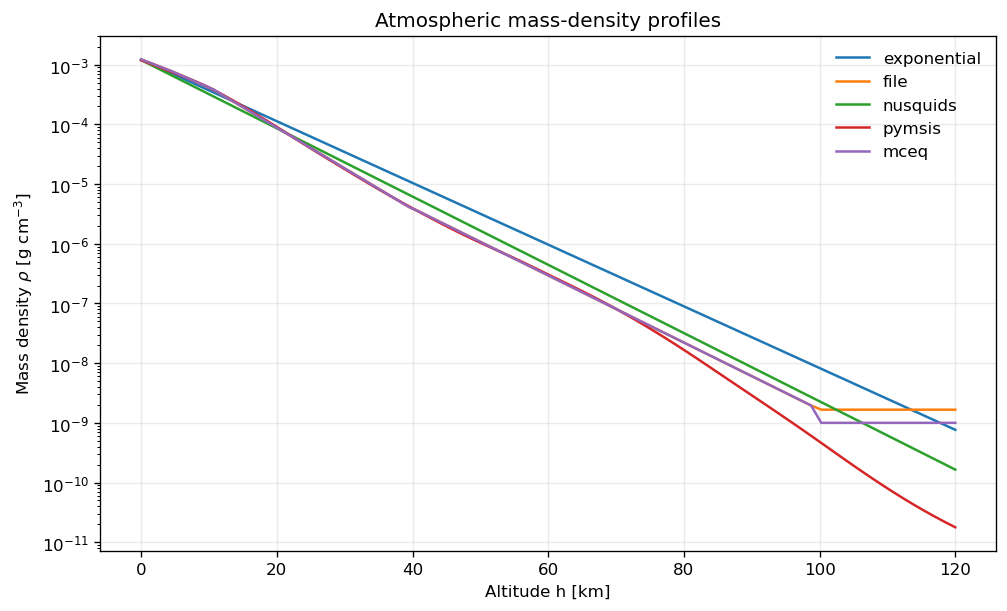

v:\output\analysis\atmosphere\atmosphere1_mass_density_profiles.png


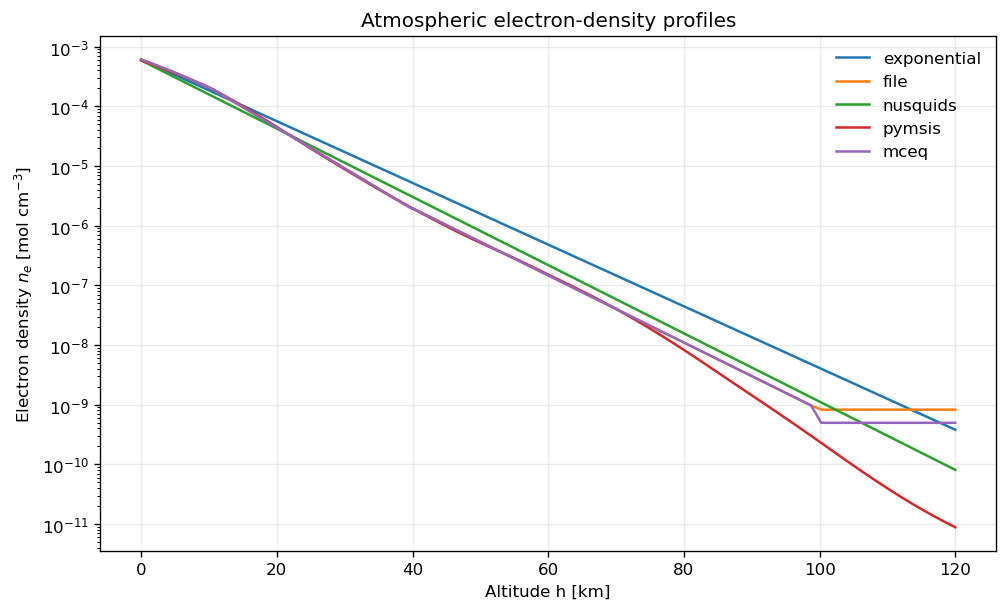

v:\output\analysis\atmosphere\atmosphere1_electron_density_profiles.png


In [16]:
DENSITY_SOURCES = ["exponential", "file", "nusquids", "pymsis", "mceq"]
density_backend_table = density_availability.copy()
electron_profiles, electron_backend_table = collect_density_profiles(ALTITUDE_GRID_KM, DENSITY_SOURCES, density_type="electron_density")
display(density_backend_table)

fig, ax = plt.subplots(figsize=(8.5, 5.2))
for source, values in mass_profiles.items():
    ax.plot(to_numpy(ALTITUDE_GRID_KM), to_numpy(values), label=source)
ax.set_xlabel("Altitude h [km]")
ax.set_ylabel(r"Mass density $\rho$ [g cm$^{-3}$]")
ax.set_yscale("log")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
ax.set_title("Atmospheric mass-density profiles")
fig.tight_layout()
save_and_show("atmosphere1_mass_density_profiles.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

fig, ax = plt.subplots(figsize=(8.5, 5.2))
for source, values in electron_profiles.items():
    ax.plot(to_numpy(ALTITUDE_GRID_KM), to_numpy(values), label=source)
ax.set_xlabel("Altitude h [km]")
ax.set_ylabel(r"Electron density $n_e$ [mol cm$^{-3}$]")
ax.set_yscale("log")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
ax.set_title("Atmospheric electron-density profiles")
fig.tight_layout()
save_and_show("atmosphere1_electron_density_profiles.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 6.2 Ratio Between Density Profiles

Ratios are often more informative than absolute densities when profiles span many orders of magnitude.

**Expected results:** ratios should remain close to one only where the simplified profile matches the reference assumptions.

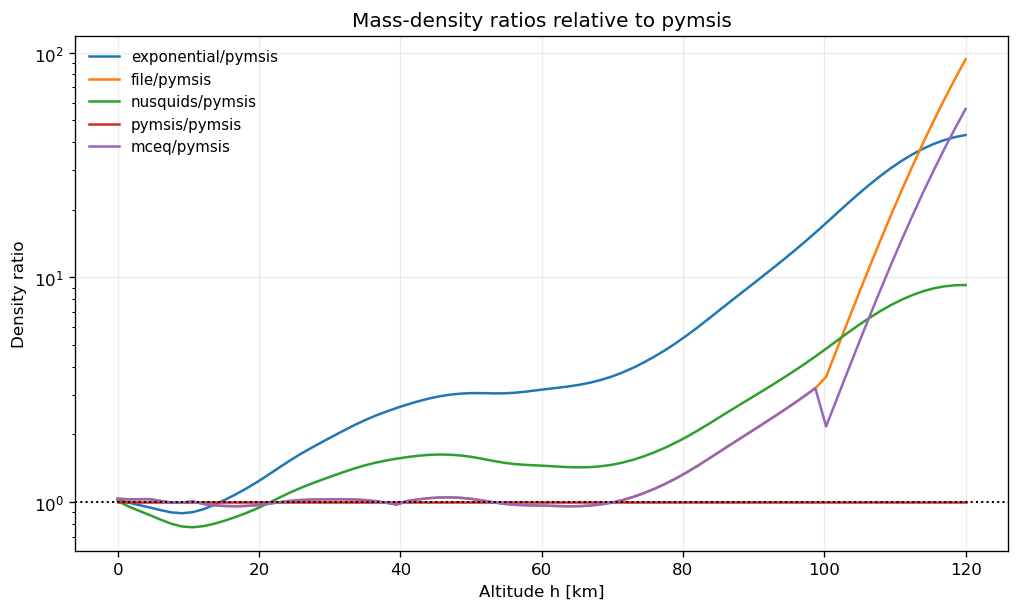

v:\output\analysis\atmosphere\atmosphere1_density_profile_ratios.png


In [12]:
reference_source = "pymsis" if "pymsis" in mass_profiles else "file" if "file" in mass_profiles else next(iter(mass_profiles))
reference_density = to_numpy(mass_profiles[reference_source])
fig, ax = plt.subplots(figsize=(8.6, 5.2))
for source, values in mass_profiles.items():
    ratio = to_numpy(values) / np.maximum(reference_density, 1.0e-40)
    ax.plot(to_numpy(ALTITUDE_GRID_KM), ratio, label=f"{source}/{reference_source}")
ax.axhline(1.0, color="black", linestyle=":", linewidth=1.2)
ax.set_xlabel("Altitude h [km]")
ax.set_ylabel("Density ratio")
ax.set_yscale("log")
ax.set_title(f"Mass-density ratios relative to {reference_source}")
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
save_and_show("atmosphere1_density_profile_ratios.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 7. Difference with respect to PyMSIS Reference

When PyMSIS is available, it is used as the empirical reference profile. Otherwise, the bundled MCEq density table is used as fallback.

**Expected results:** simplified profiles should show smooth systematic deviations; empirical/tabulated profiles need not be identical because their atmosphere assumptions differ.

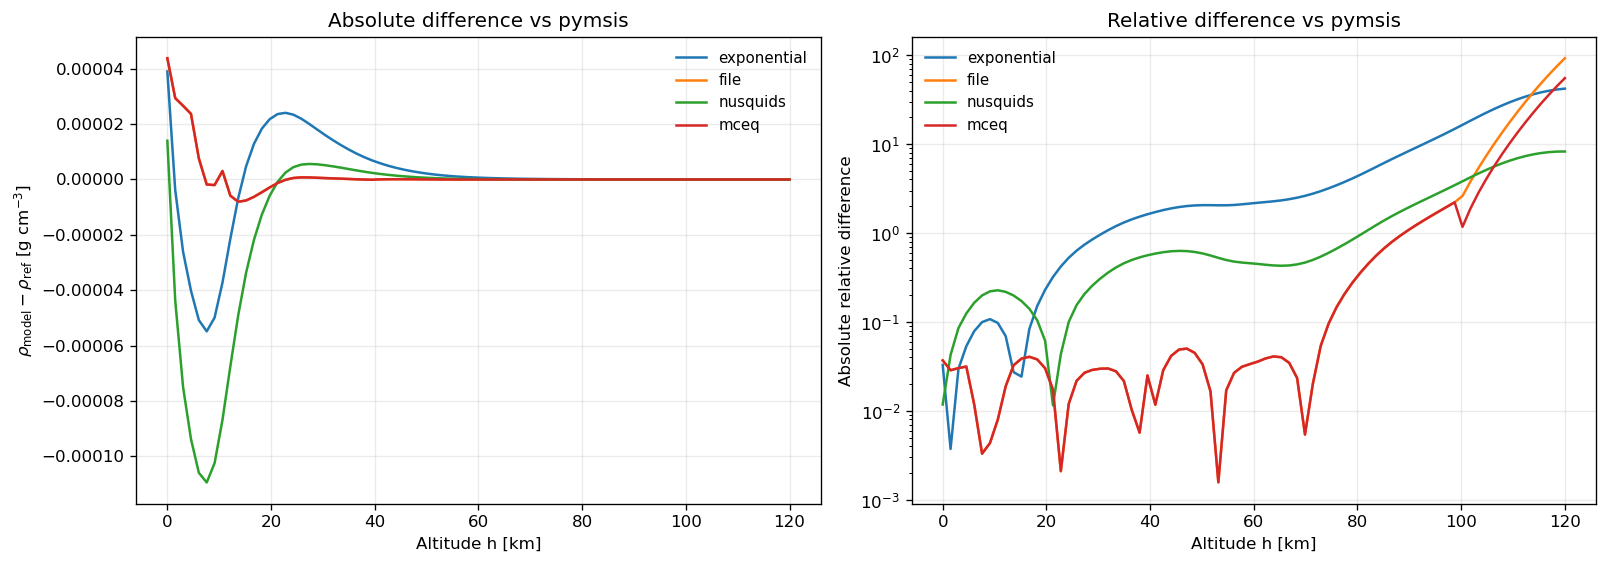

v:\output\analysis\atmosphere\atmosphere1_density_difference_vs_reference.png


,source,reference,max_abs_delta_gcm3,median_abs_delta_gcm3,max_abs_rel_delta,median_abs_rel_delta
0,exponential,pymsis,0.000055,6.649882e-07,42.009710,2.165888
1,file,pymsis,0.000044,9.408954e-09,92.351960,0.038756
2,nusquids,pymsis,0.000109,1.393603e-07,8.249523,0.550353
3,mceq,pymsis,0.000044,9.410345e-09,55.187189,0.038772


In [13]:
reference_source = "pymsis" if "pymsis" in mass_profiles else "file" if "file" in mass_profiles else next(iter(mass_profiles))
reference = to_numpy(mass_profiles[reference_source])
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), sharex=True)
residual_rows = []
for source, values in mass_profiles.items():
    if source == reference_source:
        continue
    values_np = to_numpy(values)
    abs_delta = values_np - reference
    rel_delta = safe_rel_delta(values_np, reference)
    axes[0].plot(to_numpy(ALTITUDE_GRID_KM), abs_delta, label=source)
    axes[1].plot(to_numpy(ALTITUDE_GRID_KM), np.abs(rel_delta), label=source)
    residual_rows.append({
        "source": source,
        "reference": reference_source,
        "max_abs_delta_gcm3": float(np.max(np.abs(abs_delta))),
        "median_abs_delta_gcm3": float(np.median(np.abs(abs_delta))),
        "max_abs_rel_delta": float(np.max(np.abs(rel_delta))),
        "median_abs_rel_delta": float(np.median(np.abs(rel_delta))),
    })
axes[0].set_ylabel(r"$\rho_\mathrm{model}-\rho_\mathrm{ref}$ [g cm$^{-3}$]")
axes[1].set_ylabel("Absolute relative difference")
axes[1].set_yscale("log")
for ax in axes:
    ax.set_xlabel("Altitude h [km]")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=9)
axes[0].set_title(f"Absolute difference vs {reference_source}")
axes[1].set_title(f"Relative difference vs {reference_source}")
fig.tight_layout()
save_and_show("atmosphere1_density_difference_vs_reference.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)
density_residual_table = pd.DataFrame(residual_rows)
display(density_residual_table)

### 7.2 Altitude Regions Where Each Approximation Breaks Down

Residuals are grouped by altitude band to identify whether deviations come from the lower atmosphere, stratospheric region, or high atmosphere.

**Expected results:** simplified profiles should be most reliable for broad low-altitude trends and less reliable where empirical models include temperature, solar-activity and composition effects.

In [14]:
bands = [(0, 10), (10, 30), (30, 80), (80, 120)]
band_rows = []
h_np = to_numpy(ALTITUDE_GRID_KM)
for source, values in mass_profiles.items():
    if source == reference_source:
        continue
    rel = np.abs(safe_rel_delta(to_numpy(values), reference))
    for lo, hi in bands:
        mask = (h_np >= lo) & (h_np < hi)
        if np.any(mask):
            band_rows.append({
                "source": source,
                "reference": reference_source,
                "altitude_band_km": f"{lo}-{hi}",
                "median_abs_rel_delta": float(np.median(rel[mask])),
                "max_abs_rel_delta": float(np.max(rel[mask])),
            })
density_band_table = pd.DataFrame(band_rows)
display(density_band_table)

,source,reference,altitude_band_km,median_abs_rel_delta,max_abs_rel_delta
0,exponential,pymsis,0-10,0.053393,0.107574
1,exponential,pymsis,10-30,0.229529,0.846820
2,exponential,pymsis,30-80,2.056392,4.097629
3,exponential,pymsis,80-120,15.628594,41.100515
4,file,pymsis,0-10,0.028635,0.036929
5,file,pymsis,10-30,0.026820,0.040548
6,file,pymsis,30-80,0.031323,0.274458
7,file,pymsis,80-120,2.411909,75.262331
8,nusquids,pymsis,0-10,0.124595,0.220878
9,nusquids,pymsis,10-30,0.154577,0.256314


## 8. Summary

The table below collects the main diagnostics produced by this notebook. It is generated from the computed geometry and density tables so that it reflects the current configuration.

**Physical interpretation:**

 - Detector depth has a small but measurable effect on near-horizon angle mappings and underground chord lengths.
 - Atmospheric chord lengths grow strongly near the horizon, which is why slant depth and density modelling are important for atmospheric-neutrino calculations. Density backends agree qualitatively on the steep decrease of atmospheric density with altitude, but their residuals quantify the systematic uncertainty introduced by simplified atmosphere models.

In [15]:
summary_rows = [
    {
        "diagnostic": "max horizon shift",
        "value": angle_geometry_table["horizon_shift_deg"].max(),
        "unit": "deg",
        "interpretation": "largest detector-depth correction to the near-horizon angle map",
    },
    {
        "diagnostic": "max atmospheric chord",
        "value": chord_table["L_atm_km"].max(),
        "unit": "km",
        "interpretation": "longest atmospheric segment in the configured theta/depth probes",
    },
    {
        "diagnostic": "max underground chord",
        "value": chord_table["L_earth_km"].max(),
        "unit": "km",
        "interpretation": "largest Earth segment in the configured theta/depth probes",
    },
    {
        "diagnostic": "density backends available",
        "value": int(density_backend_table["available"].sum()),
        "unit": "count",
        "interpretation": "number of density sources successfully evaluated",
    },
]
if not density_residual_table.empty:
    summary_rows.append({
        "diagnostic": f"largest density residual vs {reference_source}",
        "value": density_residual_table["max_abs_rel_delta"].max(),
        "unit": "relative",
        "interpretation": "largest relative deviation among non-reference density profiles",
    })
atmosphere_summary = pd.DataFrame(summary_rows)
display(atmosphere_summary)
print(f"Figures saved in: {OUTPUT_DIR}")

,diagnostic,value,unit,interpretation
0,max horizon shift,2.030423,deg,largest detector-depth correction to the near-...
1,max atmospheric chord,505.212826,km,longest atmospheric segment in the configured ...
2,max underground chord,12742.000000,km,largest Earth segment in the configured theta/...
3,density backends available,5.000000,count,number of density sources successfully evaluated
4,largest density residual vs pymsis,92.351960,relative,largest relative deviation among non-reference...


Figures saved in: v:\output\analysis\atmosphere
